In [1]:
import os
os.chdir('../../../../..')

In [53]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pyriemann.tangentspace import TangentSpace
import umap

import seaborn as sns
from loguru import logger
from sklearn.manifold import TSNE, MDS
import gc
import logging
import time
from typing import Any, Dict, List, Sequence, Tuple
from ase import Atoms
from dscribe.descriptors import SOAP
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from scipy.spatial.distance import pdist, squareform
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset


# =============================================================================
# MAIN EXPERIMENT
# =============================================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.covariance import oas

# Ensure third-party geometry frameworks are installed in the active environment:
# pip install pot ripser persim dscribe
import ot  # Python Optimal Transport (POT)
import persim
from dscribe.kernels import REMatchKernel
from ripser import ripser
from tqdm import tqdm

from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, PersistentHomology
from src.optimal_transport import Wasserstein, REMatch
from src.helper_functions import create_chemiscope_viewer



logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("ScalingFrontier")

In [3]:
qm9 = QM9Dataset(limit=80_000, descriptors=["soap"])
df = qm9.load()

2026-06-07 14:22:12.244 | INFO     | src.datasets:_load_full_qm9_df:846 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-07 14:22:12.761 | INFO     | src.datasets:_sample_qm9_df:1029 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-06-07 14:22:12.763 | INFO     | src.datasets:_add_requested_descriptors:204 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-06-07 14:22:12.859 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-06-07 14:25:42.147 | SUCCESS  | src.datasets:add_soap:1222 - Added SOAP embeddings and matrices.
2026-06-07 14:25:42.382 | INFO     | src.datasets:_add_requested_descriptors:215 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-06-07 14:25:42.584 | INFO     | src.datasets:_load_with_descriptor_filter:886 - QM9 descriptor null-filtering 

# Hypothesis 1
- an experiment showing the time benefit of grassmann compared to riemann and rematch kernel

In [ ]:
class EuclideanProfiler:
    """Computes a standard Euclidean distance baseline between globally averaged

    molecular feature representations ('soap_embedding' simulation).
    """

    @classmethod
    def compute_descriptors(cls, raw_matrices: list) -> np.ndarray:
        # Replicates standard global average pooling over local environments
        pooled_vectors = [np.mean(X, axis=0) for X in raw_matrices]
        return np.array(pooled_vectors)

    @classmethod
    def compute_distances(cls, X_pooled: np.ndarray) -> np.ndarray:
        return squareform(pdist(X_pooled, metric="euclidean"))


class GrassmannProfiler:
    """Optimized Grassmannian framework locked strictly to the right singular vectors

    to guarantee shape invariance across molecules with varying atom counts.
    """

    @classmethod
    def compute_descriptors(cls, raw_matrices: list, k: int = 3) -> list:
        bases = []
        for X in raw_matrices:
            _, _, vh = np.linalg.svd(X, full_matrices=False)
            bases.append(vh.T[:, :k])
        return bases

    @classmethod
    def compute_distances(cls, bases: list) -> np.ndarray:
        num_items = len(bases)
        dist_matrix = np.zeros((num_items, num_items))
        bases_T = [U.T for U in bases]

        for i in range(num_items):
            U1_T = bases_T[i]
            for j in range(i + 1, num_items):
                core_matrix = U1_T @ bases[j]
                s = np.linalg.svd(core_matrix, compute_uv=False)
                angles = np.arccos(np.clip(s, 0.0, 1.0))
                d = float(np.linalg.norm(angles))  # Geodesic distance
                dist_matrix[i, j] = dist_matrix[j, i] = d
        return dist_matrix


class RiemannProfiler:
    """Handles Log-Euclidean Tangent Space representation profiling."""

    @classmethod
    def compute_descriptors(cls, raw_matrices: list) -> np.ndarray:
        vectorized_dataset = []
        for X in raw_matrices:
            X_centered = X - np.mean(X, axis=0)
            C, _ = oas(X_centered, assume_centered=True)

            eigenvalues, eigenvectors = np.linalg.eigh(C)
            eigenvalues = np.clip(eigenvalues, a_min=1e-12, a_max=None)
            log_C = eigenvectors @ np.diag(np.log(eigenvalues)) @ eigenvectors.T

            d = log_C.shape[0]
            triu_idx = np.triu_indices(d)
            weight_matrix = np.where(np.eye(d, dtype=bool), 1.0, np.sqrt(2.0))
            weighted_log_C = log_C * weight_matrix
            vectorized_dataset.append(weighted_log_C[triu_idx])

        return np.array(vectorized_dataset)

    @classmethod
    def compute_distances(cls, X_tangent: np.ndarray) -> np.ndarray:
        return squareform(pdist(X_tangent, metric="euclidean"))


class REMatchProfiler:
    """Authentic profiling wrapper utilizing the true dscribe REMatchKernel engine."""

    @classmethod
    def compute_distances(
        cls, raw_matrices: list, metric="linear", alpha=0.1, tol=1e-3
    ) -> np.ndarray:
        cleaned = []
        for i, x in enumerate(raw_matrices):
            x = np.asarray(x, dtype=np.float64)
            if x.ndim != 2:
                raise ValueError(f"SOAP matrix {i} is not 2D: shape={x.shape}")
            if not np.isfinite(x).all():
                raise ValueError(f"Non-finite values in SOAP matrix {i}")

            norms = np.linalg.norm(x, axis=1)
            x_norm = (
                x
                if np.all(np.abs(norms - 1.0) < tol)
                else x / (norms[:, None] + 1e-12)
            )
            cleaned.append(x_norm)

        kernel = REMatchKernel(metric=metric, alpha=alpha)
        K = kernel.create(cleaned)

        if not np.isfinite(K).all():
            raise ValueError("Kernel matrix contains NaN or inf")

        diag = np.diag(K)
        dist_sq = diag[:, None] + diag[None, :] - 2.0 * K
        dist_sq = np.clip(dist_sq, 0.0, None)
        D = np.sqrt(dist_sq)

        np.fill_diagonal(D, 0.0)
        return (D + D.T) / 2.0


class WassersteinProfiler:
    """Computes Earth Mover's Distance (Wasserstein-1) over lists of raw atomic matrices."""

    @classmethod
    def compute_distances(
        cls, raw_matrices: list, metric: str = "sqeuclidean"
    ) -> np.ndarray:
        num_items = len(raw_matrices)
        if num_items == 0:
            return np.array([])

        dist_matrix = np.zeros((num_items, num_items))
        weights = [np.ones(X.shape[0]) / X.shape[0] for X in raw_matrices]

        for i in range(num_items):
            X_i = np.asarray(raw_matrices[i])
            w_i = weights[i]

            for j in range(i + 1, num_items):
                X_j = np.asarray(raw_matrices[j])
                w_j = weights[j]

                try:
                    M = ot.dist(X_i, X_j, metric=metric)
                    d = float(ot.emd2(w_i, w_j, M))
                    dist_matrix[i, j] = dist_matrix[j, i] = d
                except Exception as e:
                    dist_matrix[i, j] = dist_matrix[j, i] = np.nan

        if np.isnan(dist_matrix).any():
            dist_matrix = np.nan_to_num(dist_matrix, nan=np.nanmax(dist_matrix))
        return dist_matrix


class PersistentHomologyProfiler:
    """Computes topological features directly from high-dimensional feature matrices

    treated as continuous point clouds.
    """

    @classmethod
    def compute_distances(
        cls,
        raw_matrices: list,
        metric: str = "bottleneck",
        max_homology_dim: int = 1,
        homology_dims: Sequence[int] = (0, 1),
        sw_projections: int = 20,
    ) -> Tuple[np.ndarray, List[Dict[int, np.ndarray]]]:
        metric_key = metric.lower()

        dgms = []
        for X in raw_matrices:
            X_arr = np.asarray(X, dtype=np.float64)
            if len(X_arr) == 0:
                dgms.append(
                    {
                        d: np.empty((0, 2))
                        for d in range(max_homology_dim + 1)
                    }
                )
                continue

            dist_mat = cdist(X_arr, X_arr, metric="euclidean")
            raw_dgms = ripser(
                dist_mat, maxdim=max_homology_dim, distance_matrix=True
            )["dgms"]

            formatted_dgm = {}
            for d in range(max_homology_dim + 1):
                dgm_layer = np.asarray(raw_dgms[d])
                if len(dgm_layer) > 0:
                    dgm_layer = dgm_layer[np.isfinite(dgm_layer[:, 1])]
                formatted_dgm[d] = dgm_layer
            dgms.append(formatted_dgm)

        num_items = len(dgms)
        dist_matrix = np.zeros((num_items, num_items))

        for i in range(num_items):
            dgm_i = dgms[i]
            for j in range(i + 1, num_items):
                dgm_j = dgms[j]
                total_dist = 0.0

                for d in homology_dims:
                    p1 = dgm_i.get(d, np.empty((0, 2)))
                    p2 = dgm_j.get(d, np.empty((0, 2)))

                    if len(p1) == 0 and len(p2) == 0:
                        continue

                    if metric_key in {"bottleneck", "b"}:
                        total_dist += persim.bottleneck(p1, p2)
                    else:
                        total_dist += persim.sliced_wasserstein(
                            p1, p2, M=sw_projections
                        )

                dist_matrix[i, j] = dist_matrix[j, i] = float(total_dist)

        if np.isnan(dist_matrix).any():
            dist_matrix = np.nan_to_num(dist_matrix, nan=np.nanmax(dist_matrix))
        return dist_matrix, dgms


# =============================================================================
# BENCHMARK ENGINE
# =============================================================================


def run_scaling_frontier_experiment():
    # Experimental dimensions
    M_molecules = 100  # Bounded size to secure runtime scaling
    N_atoms = 25  # Target atoms per molecule
    D_dimensions = [64, 128, 256, 512, 1024, 2048]  # Full resolution sweep
    k_grassmann = 4  # Fixed subspace rank

    results = []

    print(
        f"Starting Benchmark | Configuration: M={M_molecules} Molecules, N={N_atoms} Atoms"
    )
    print("=" * 145)

    for D in D_dimensions:
        print(f"Evaluating Feature Dimensionality: D = {D}...")

        np.random.seed(42)
        raw_data = [np.random.randn(N_atoms, D) for _ in range(M_molecules)]

        # --- Base Input Descriptors Footprint ---
        mem_raw_mb = sum(X.nbytes for X in raw_data) / (1024**2)

        # 0. PROFILE EUCLIDEAN BASELINE ('soap_embedding' simulation)
        t0 = time.perf_counter()
        X_pooled = EuclideanProfiler.compute_descriptors(raw_data)
        _ = EuclideanProfiler.compute_distances(X_pooled)
        t_euclidean = time.perf_counter() - t0
        mem_euclidean_mb = X_pooled.nbytes / (1024**2)

        # 1. PROFILE REMATCH
        t0 = time.perf_counter()
        _ = REMatchProfiler.compute_distances(raw_data)
        t_rematch = time.perf_counter() - t0
        # REMatch acts straight on local matrices; memory requirement maps to raw allocation
        mem_rematch_mb = mem_raw_mb

        # 2. PROFILE RIEMANN
        t0 = time.perf_counter()
        X_tangent = RiemannProfiler.compute_descriptors(raw_data)
        _ = RiemannProfiler.compute_distances(X_tangent)
        t_riemann = time.perf_counter() - t0
        mem_riemann_mb = X_tangent.nbytes / (1024**2)

        # 3. PROFILE GRASSMANNIAN
        t0 = time.perf_counter()
        bases = GrassmannProfiler.compute_descriptors(raw_data, k=k_grassmann)
        _ = GrassmannProfiler.compute_distances(bases)
        t_grassmann = time.perf_counter() - t0
        mem_grassmann_mb = sum(B.nbytes for B in bases) / (1024**2)

        # 4. PROFILE WASSERSTEIN (EMD)
        t0 = time.perf_counter()
        _ = WassersteinProfiler.compute_distances(raw_data)
        t_wasserstein = time.perf_counter() - t0
        mem_wasserstein_mb = mem_raw_mb

        # 5. PROFILE PERSISTENT HOMOLOGY
        t0 = time.perf_counter()
        _, dgms = PersistentHomologyProfiler.compute_distances(
            raw_data, metric="bottleneck"
        )
        t_ph = time.perf_counter() - t0
        # Tracks memory trace of calculated structural persistence diagrams
        mem_ph_mb = (
            sum(layer.nbytes for dgm in dgms for layer in dgm.values())
            / (1024**2)
        )

        results.append(
            {
                "D": D,
                "Euclidean (s)": t_euclidean,
                "Euclid Mem (MB)": mem_euclidean_mb,
                "REMatch (s)": t_rematch,
                "REMatch Mem (MB)": mem_rematch_mb,
                "Riemann (s)": t_riemann,
                "Riemann Mem (MB)": mem_riemann_mb,
                "Grassmann (s)": t_grassmann,
                "Grass Mem (MB)": mem_grassmann_mb,
                "Wasserstein (s)": t_wasserstein,
                "Wasser Mem (MB)": mem_wasserstein_mb,
                "PH Topology (s)": t_ph,
                "PH Mem (MB)": mem_ph_mb,
            }
        )

        del raw_data, X_pooled, X_tangent, bases, dgms
        gc.collect()

    df_results = pd.DataFrame(results)

    print("\n" + "=" * 145)
    print(" FINAL EXPERIMENTAL PERFORMANCE SUMMARY")
    print("=" * 145)
    print(df_results.to_markdown(index=False, floatfmt=".4f"))
    print("=" * 145)

if __name__ == "__main__":
    run_scaling_frontier_experiment()

Starting Benchmark | Configuration: M=100 Molecules, N=25 Atoms
Evaluating Feature Dimensionality: D = 64...


KeyboardInterrupt: 

In [ ]:
run_scaling_frontier_experiment()

Starting Benchmark | Configuration: M=60 Molecules, N=24 Atoms
Evaluating Feature Dimensionality: D = 64...
Evaluating Feature Dimensionality: D = 128...
Evaluating Feature Dimensionality: D = 256...
Evaluating Feature Dimensionality: D = 512...
Evaluating Feature Dimensionality: D = 1024...
Evaluating Feature Dimensionality: D = 2048...

 FINAL EXPERIMENTAL PERFORMANCE SUMMARY
|         D |   Time REMatch (s) |   Mem REMatch (MB) |   Time Riemann (s) |   Mem Riemann (MB) |   Time Grassmann (s) |   Mem Grassmann (MB) |
|----------:|-------------------:|-------------------:|-------------------:|-------------------:|---------------------:|---------------------:|
|   64.0000 |             0.2141 |             0.7031 |             0.0388 |             0.9521 |               0.0226 |               0.1172 |
|  128.0000 |             0.1841 |             1.4062 |             0.1060 |             3.7793 |               0.0269 |               0.2344 |
|  256.0000 |             0.1858 |         

# Hypothesis 2
- grassmann will be resisient to noise in the coordinates

In [54]:
def run_robustness_benchmark(
    df_base: pl.DataFrame,
    n_parent_mols: int = 6,
    n_perturbations: int = 20,
    k_grassmann_list: List[int] = [2, 5, 10, 15, 20, 25]
) -> Dict[str, Any]:
    """Executes a structural robustness benchmark comparing distance drift and parent
    retrieval accuracy across structural, geometric, and topological spaces.
    
    Returns:
        A dictionary containing the sigma levels, framework names, and compiled metrics.
    """
    df_parents = df_base.sample(n_parent_mols, seed=42)

    flat_atomic_numbers = [
        num for sublist in df_parents["atomic_numbers"].to_list() for num in sublist
    ]
    species = sorted(list(set(flat_atomic_numbers)))

    soap = SOAP(
        species=species,
        r_cut=5.0,
        n_max=4,
        l_max=3,
        periodic=False,
        sparse=False
    )

    sigma_levels = [0.00, 0.01, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
    
    frameworks = [
        "Average SOAP",
        "Wasserstein W1",
        "Wasserstein W2",
        "REMatch",
        "Riemann", 
    ] + [f"Grassmann (k={k})" for k in k_grassmann_list]

    metrics = {
        fw: {"drift": [], "retrieval_acc": []} for fw in frameworks
    }
    
    physical_displacements = []
    print("Running robustness benchmark (Physical Deformation, Drift & Retrieval)...")

    # 2. PRECOMPUTE CLEAN REFERENCES
    clean_records = []
    for i, row in enumerate(df_parents.iter_rows(named=True)):
        nums = row["atomic_numbers"]
        coords = np.array(row["coordinates"], dtype=np.float64)
        clean_soap = soap.create(Atoms(numbers=nums, positions=coords))
        
        avg_soap = np.mean(clean_soap, axis=0).tolist()
        
        clean_records.append({
            "parent_idx": i,
            "is_clean": True,
            "soap_matrix": clean_soap.tolist(),
            "average_soap": avg_soap, 
            "coordinates": coords.tolist(),
            "atomic_numbers": nums
        })

    # 3. MAIN LOOP OVER NOISE LEVELS
    for sigma in sigma_levels:
        print(f"Evaluating Sigma = {sigma}")

        all_records = list(clean_records) 
        current_sigma_displacements = []
        
        if sigma > 0.0:
            for clean in clean_records:
                clean_coords = np.array(clean["coordinates"])
                for _ in range(n_perturbations):
                    noise = np.random.normal(0, sigma, clean_coords.shape)
                    
                    atom_distances = np.linalg.norm(noise, axis=1)
                    current_sigma_displacements.extend(atom_distances)
                    
                    noisy_coords = clean_coords + noise
                    pert = Atoms(numbers=clean["atomic_numbers"], positions=noisy_coords)
                    noisy_soap = soap.create(pert)
                    
                    noisy_avg_soap = np.mean(noisy_soap, axis=0).tolist()
                    
                    all_records.append({
                        "parent_idx": clean["parent_idx"],
                        "is_clean": False,
                        "soap_matrix": noisy_soap.tolist(),
                        "average_soap": noisy_avg_soap, 
                        "coordinates": noisy_coords.tolist(), 
                        "atomic_numbers": clean["atomic_numbers"]
                    })
            
            physical_displacements.append(np.mean(current_sigma_displacements))
        else:
            physical_displacements.append(0.0)

        df = pl.DataFrame(all_records)
        
        idx_clean = df.with_row_index().filter(pl.col("is_clean")).select("index").to_series().to_list()
        idx_noisy = df.with_row_index().filter(~pl.col("is_clean")).select("index").to_series().to_list()

        # 4. COMPUTE PAIRWISE DISTANCE MATRIX FRONTIERS
        matrices = {}
        matrices["Wasserstein W1"] = Wasserstein.distance_matrix(df, "soap", metric="euclidean")
        matrices["Wasserstein W2"] = Wasserstein.distance_matrix(df, "soap", metric="sqeuclidean")
        matrices["REMatch"] = REMatch.distance_matrix(df, "soap", metric="linear", alpha=0.1)
        matrices["Riemann"] = Riemann.distance_matrix(df, "soap", distance_type="log-euclidean")
        
        X_avg = np.vstack(df["average_soap"].to_list())
        matrices["Average SOAP"] = squareform(pdist(X_avg, metric="euclidean"))
        
        for k in k_grassmann_list:
            matrices[f"Grassmann (k={k})"] = Grassmann().distance_matrix(df, "soap", distance_type="geodesic", k=k)

        # Baseline execution tracking
        if sigma == 0.0:
            for fw in frameworks:
                metrics[fw]["drift"].append(0.0)
                metrics[fw]["retrieval_acc"].append(1.0)
            continue

        # 5. CALCULATE DRIFT AND CLASSIFICATION RETRIEVALS
        for name, M in matrices.items():
            correct_retrievals = 0
            drift_vals = []
            
            for noisy_i in idx_noisy:
                true_parent = df["parent_idx"][noisy_i]
                distances_to_cleans = M[noisy_i, idx_clean]
                predicted_parent = np.argmin(distances_to_cleans)
                
                if predicted_parent == true_parent:
                    correct_retrievals += 1
                    
                drift_vals.append(distances_to_cleans[true_parent])

            metrics[name]["retrieval_acc"].append(correct_retrievals / len(idx_noisy))
            metrics[name]["drift"].append(np.mean(drift_vals))

    # Package findings cleanly for the visualizer pipeline
    return {
        "sigma_levels": sigma_levels,
        "frameworks": frameworks,
        "metrics": metrics
    }

In [61]:
def plot_robustness_results(benchmark_data: Dict[str, Any]) -> None:
    """Generates the high-resolution, enhanced visualization platform to 
    unambiguously contrast geometric resilience across tracking spaces
    by plotting parent structure retrieval accuracy with maximized color clarity.
    """
    sigma_levels = benchmark_data["sigma_levels"]
    frameworks = benchmark_data["frameworks"]
    metrics = benchmark_data["metrics"]

    # Filter down grassmann instances to properly parse color ramps dynamically
    grassmann_frameworks = [fw for fw in frameworks if "Grassmann" in fw]

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # 1. ENHANCED GRASSMANN COLOR RAMP (Using 'YlGnBu' or 'viridis' for distinct step visibility)
    cmap_grassmann = plt.cm.get_cmap("YlGnBu")
    num_g = max(1, len(grassmann_frameworks))
    # Using the 0.4 to 0.95 range ensures the lines stay vivid and readable against white backgrounds
    grassmann_colors = [cmap_grassmann(0.4 + 0.55 * (i / num_g)) for i in range(num_g)]
    
    # 2. HIGH-CONTRAST DESATURATED BASELINE PALETTE
    # Separates baselines via distinct structural color identities (Gray, Charcoal, Amber-Brown, Indigo-Purple)
    colors = {
        "Average SOAP": "#64748b",     # Slate Gray
        "Wasserstein W1": "#4b5563",   # Deep Charcoal
        "Wasserstein W2": "#b45309",   # Muted Amber/Brown
        "REMatch": "#6d28d9",          # Muted Indigo
        "Riemann": "#dc2626",          # Pure Champion Crimson (Demands immediate focus)
    }
    
    g_idx = 0
    for fw in frameworks:
        if "Grassmann" in fw:
            colors[fw] = grassmann_colors[g_idx]
            g_idx += 1

    # Plot Parent Retrieval Tracking Curves
    for fw in frameworks:
        is_riemann = (fw == "Riemann")
        is_baseline = (fw in ["Average SOAP", "Wasserstein W1", "Wasserstein W2", "REMatch"])
        
        # Style adjustments to clearly distinguish group types
        lw = 2.5 if is_riemann else 1.5
        zo = 10 if is_riemann else (2 if is_baseline else 5)
        ls = "-" if not is_baseline else "--"  # Dashed baselines lower their visual weight
        
        # Fallback dictionary tracking to guarantee zero execution exceptions
        line_color = colors.get(fw, "#000000")
        
        ax.plot(
            sigma_levels, metrics[fw]["retrieval_acc"], 
            label=fw, color=line_color, 
            marker="o", markersize=4 if is_riemann else 3, 
            linewidth=lw, zorder=zo, linestyle=ls
        )
        
    ax.set_title("Parent Structure Retrieval Accuracy", fontweight="bold", pad=12)
    ax.set_xlabel("Gaussian Atomic Displacement Noise (σ)", fontsize=10)
    ax.set_ylabel("Fraction Correctly Classified", fontsize=10)
    ax.set_ylim([0.75, 1.03])  
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(frameon=True, facecolor="white", edgecolor="#e2e8f0", loc="lower left")

    plt.tight_layout()
    plt.show()

In [51]:
def run_multi_isomer_experiment(
    df: pl.DataFrame, 
    top_n_formulas: int = 3, 
    n_parent_mols: int = 10
) -> Dict[str, Any]:
    """Finds the top N chemical formulas with the most acyclic isomers, 
    runs the robustness benchmark for each formula independently, and 
    aggregates the drift and retrieval results across all formulas.
    """
    
    # 1. Identify the top N formulas meeting your criteria
    print(f"Identifying the top {top_n_formulas} chemical formulas with at least 10 acyclic isomers...")
    df_counts = (
        df.filter(pl.col("structure_class") == "Acyclic")
        .group_by("formula")
        .count()
        .filter(pl.col("count") >= 10)
        .sort("count", descending=True)
    )
    
    target_formulas = df_counts.select("formula").head(top_n_formulas).to_series().to_list()
    print(f"Selected formulas for benchmark: {target_formulas}\n" + "="*60)
    
    # Storage structures for aggregating results across iterations
    all_experiment_runs = []
    frameworks_list = None
    sigma_levels = None

    # 2. Loop through each isolated isomer space
    for formula in target_formulas:
        print(f"\n>>> RUNNING BENCHMARK FOR ISOMER GROUP: {formula} <<<")
        
        # Filter down to the isolated isomer cohort
        df_isomers = df.filter(
            (pl.col("formula") == formula) & 
            (pl.col("structure_class") == "Acyclic")
        )
        
        # Run your existing benchmark function on this isolated set
        run_data = run_robustness_benchmark(df_isomers, n_parent_mols=n_parent_mols)
        all_experiment_runs.append(run_data["metrics"])
        
        # Capture metadata parameters from the first run
        if sigma_levels is None:
            sigma_levels = run_data["sigma_levels"]
            frameworks_list = run_data["frameworks"]

    # 3. Aggregate the results (mean average) across all formula batches
    print("\n" + "="*60 + "\nAggregating multi-isomer experimental results...")
    aggregated_metrics = {
        fw: {"drift": [], "retrieval_acc": []} for fw in frameworks_list
    }
    
    # Average out the values across each noise level step index
    for fw in frameworks_list:
        for idx in range(len(sigma_levels)):
            step_drifts = [run[fw]["drift"][idx] for run in all_experiment_runs]
            step_accs = [run[fw]["retrieval_acc"][idx] for run in all_experiment_runs]
            
            aggregated_metrics[fw]["drift"].append(np.mean(step_drifts))
            aggregated_metrics[fw]["retrieval_acc"].append(np.mean(step_accs))
            
    print("Experiment complete. Final aggregated data compiled.")
    return {
        "sigma_levels": sigma_levels,
        "frameworks": frameworks_list,
        "metrics": aggregated_metrics
    }

In [55]:
final_results = run_multi_isomer_experiment(
    df=df, 
    top_n_formulas=5,
    n_parent_mols=10,
)


Identifying the top 5 chemical formulas with at least 10 acyclic isomers...


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_34039/747261597.py:16: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()
2026-06-07 15:33:08.030 | INFO     | src.optimal_transport:_feature_matrices_from_df:54 - Using column: soap_matrix from df
2026-06-07 15:33:08.037 | INFO     | src.optimal_transport:distance_matrix:408 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: euclidean


Selected formulas for benchmark: ['C6H9NO2', 'C6H12O3', 'C6H11NO2', 'C7H10O2', 'C5H10N2O2']

>>> RUNNING BENCHMARK FOR ISOMER GROUP: C6H9NO2 <<<
Running robustness benchmark (Physical Deformation, Drift & Retrieval)...
Evaluating Sigma = 0.0


Wasserstein distances: 100%|██████████| 10/10 [00:00<00:00, 1445.71row/s]
2026-06-07 15:33:08.047 | INFO     | src.optimal_transport:_feature_matrices_from_df:54 - Using column: soap_matrix from df
2026-06-07 15:33:08.052 | INFO     | src.optimal_transport:distance_matrix:408 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: sqeuclidean
Wasserstein distances: 100%|██████████| 10/10 [00:00<00:00, 1666.66row/s]
2026-06-07 15:33:08.061 | INFO     | src.optimal_transport:_feature_matrices_from_df:54 - Using column: soap_matrix from df
2026-06-07 15:33:08.067 | INFO     | src.optimal_transport:kernel_matrix:175 - Computing REMatch regularized transport kernel | Features: soap | Metric: linear | alpha: 0.1
INFO: Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
INFO: Using column: soap_matrix from df
INFO: Computing log-euclidean distances...
INFO: Using column: soap_matrix from df
INFO: Computing Grassmann distance matrix | Features: 

Evaluating Sigma = 0.01


...

Evaluating Sigma = 0.3


2026-06-07 15:49:53.305 | INFO     | src.optimal_transport:distance_matrix:408 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: euclidean
Wasserstein distances: 100%|██████████| 210/210 [00:02<00:00, 95.69row/s] 
2026-06-07 15:49:55.503 | INFO     | src.optimal_transport:_feature_matrices_from_df:54 - Using column: soap_matrix from df
2026-06-07 15:49:55.608 | INFO     | src.optimal_transport:distance_matrix:408 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: sqeuclidean
Wasserstein distances: 100%|██████████| 210/210 [00:02<00:00, 99.40row/s] 
2026-06-07 15:49:57.725 | INFO     | src.optimal_transport:_feature_matrices_from_df:54 - Using column: soap_matrix from df
2026-06-07 15:49:57.826 | INFO     | src.optimal_transport:kernel_matrix:175 - Computing REMatch regularized transport kernel | Features: soap | Metric: linear | alpha: 0.1
INFO: Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
INFO: 

Evaluating Sigma = 0.35


2026-06-07 15:50:18.786 | INFO     | src.optimal_transport:distance_matrix:408 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: euclidean
Wasserstein distances: 100%|██████████| 210/210 [00:02<00:00, 99.42row/s] 
2026-06-07 15:50:20.902 | INFO     | src.optimal_transport:_feature_matrices_from_df:54 - Using column: soap_matrix from df
2026-06-07 15:50:20.998 | INFO     | src.optimal_transport:distance_matrix:408 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: sqeuclidean
Wasserstein distances: 100%|██████████| 210/210 [00:02<00:00, 99.33row/s] 
2026-06-07 15:50:23.117 | INFO     | src.optimal_transport:_feature_matrices_from_df:54 - Using column: soap_matrix from df
2026-06-07 15:50:23.217 | INFO     | src.optimal_transport:kernel_matrix:175 - Computing REMatch regularized transport kernel | Features: soap | Metric: linear | alpha: 0.1
INFO: Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
INFO: 


Aggregating multi-isomer experimental results...
Experiment complete. Final aggregated data compiled.


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_34039/2894163661.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_grassmann = plt.cm.get_cmap("YlGnBu")


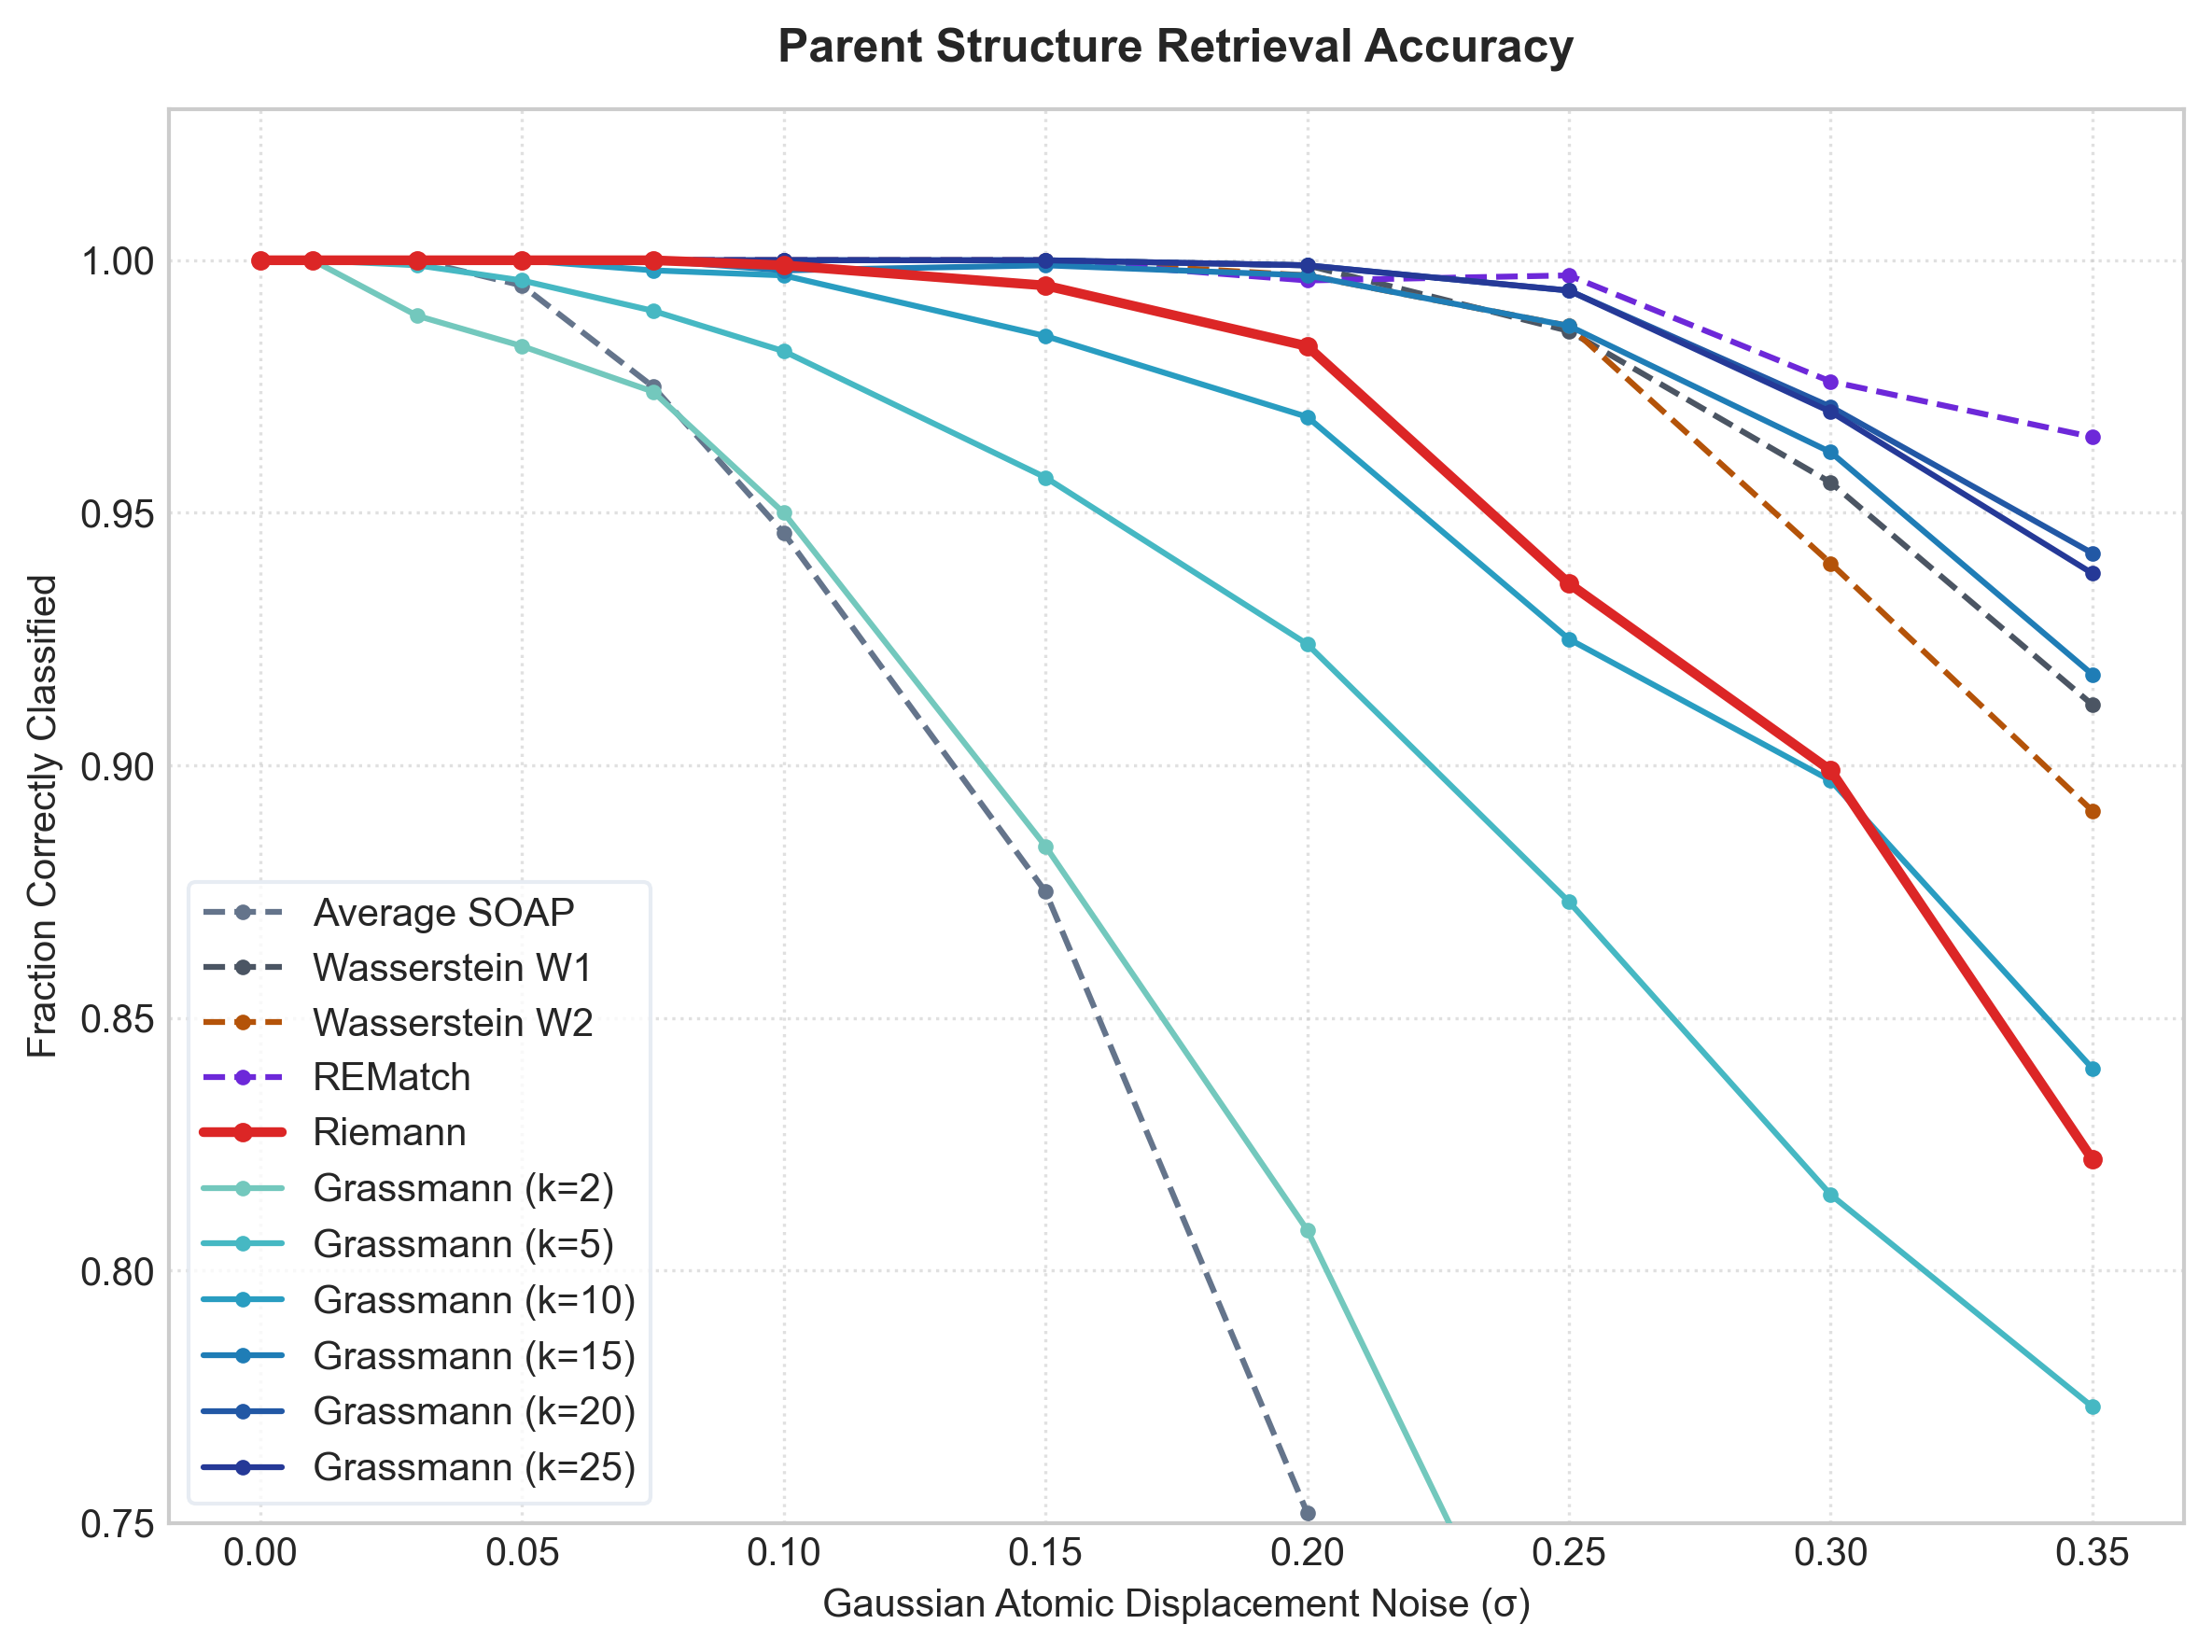

In [62]:
plot_robustness_results(final_results)

# Hypothesis 3
- invariant to system size

In [ ]:
qm9 = QM9Dataset(limit=None)
df_sample = qm9.load()

2026-05-26 14:55:21.162 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-26 14:55:21.560 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=1000, returned_rows=1000, sampling on columns=['num_atoms', 'gap'].
2026-05-26 14:55:21.561 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=1000).
2026-05-26 14:55:21.563 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-26 14:55:22.212 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-26 14:55:22.212 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-26 14:55:22.215 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering com

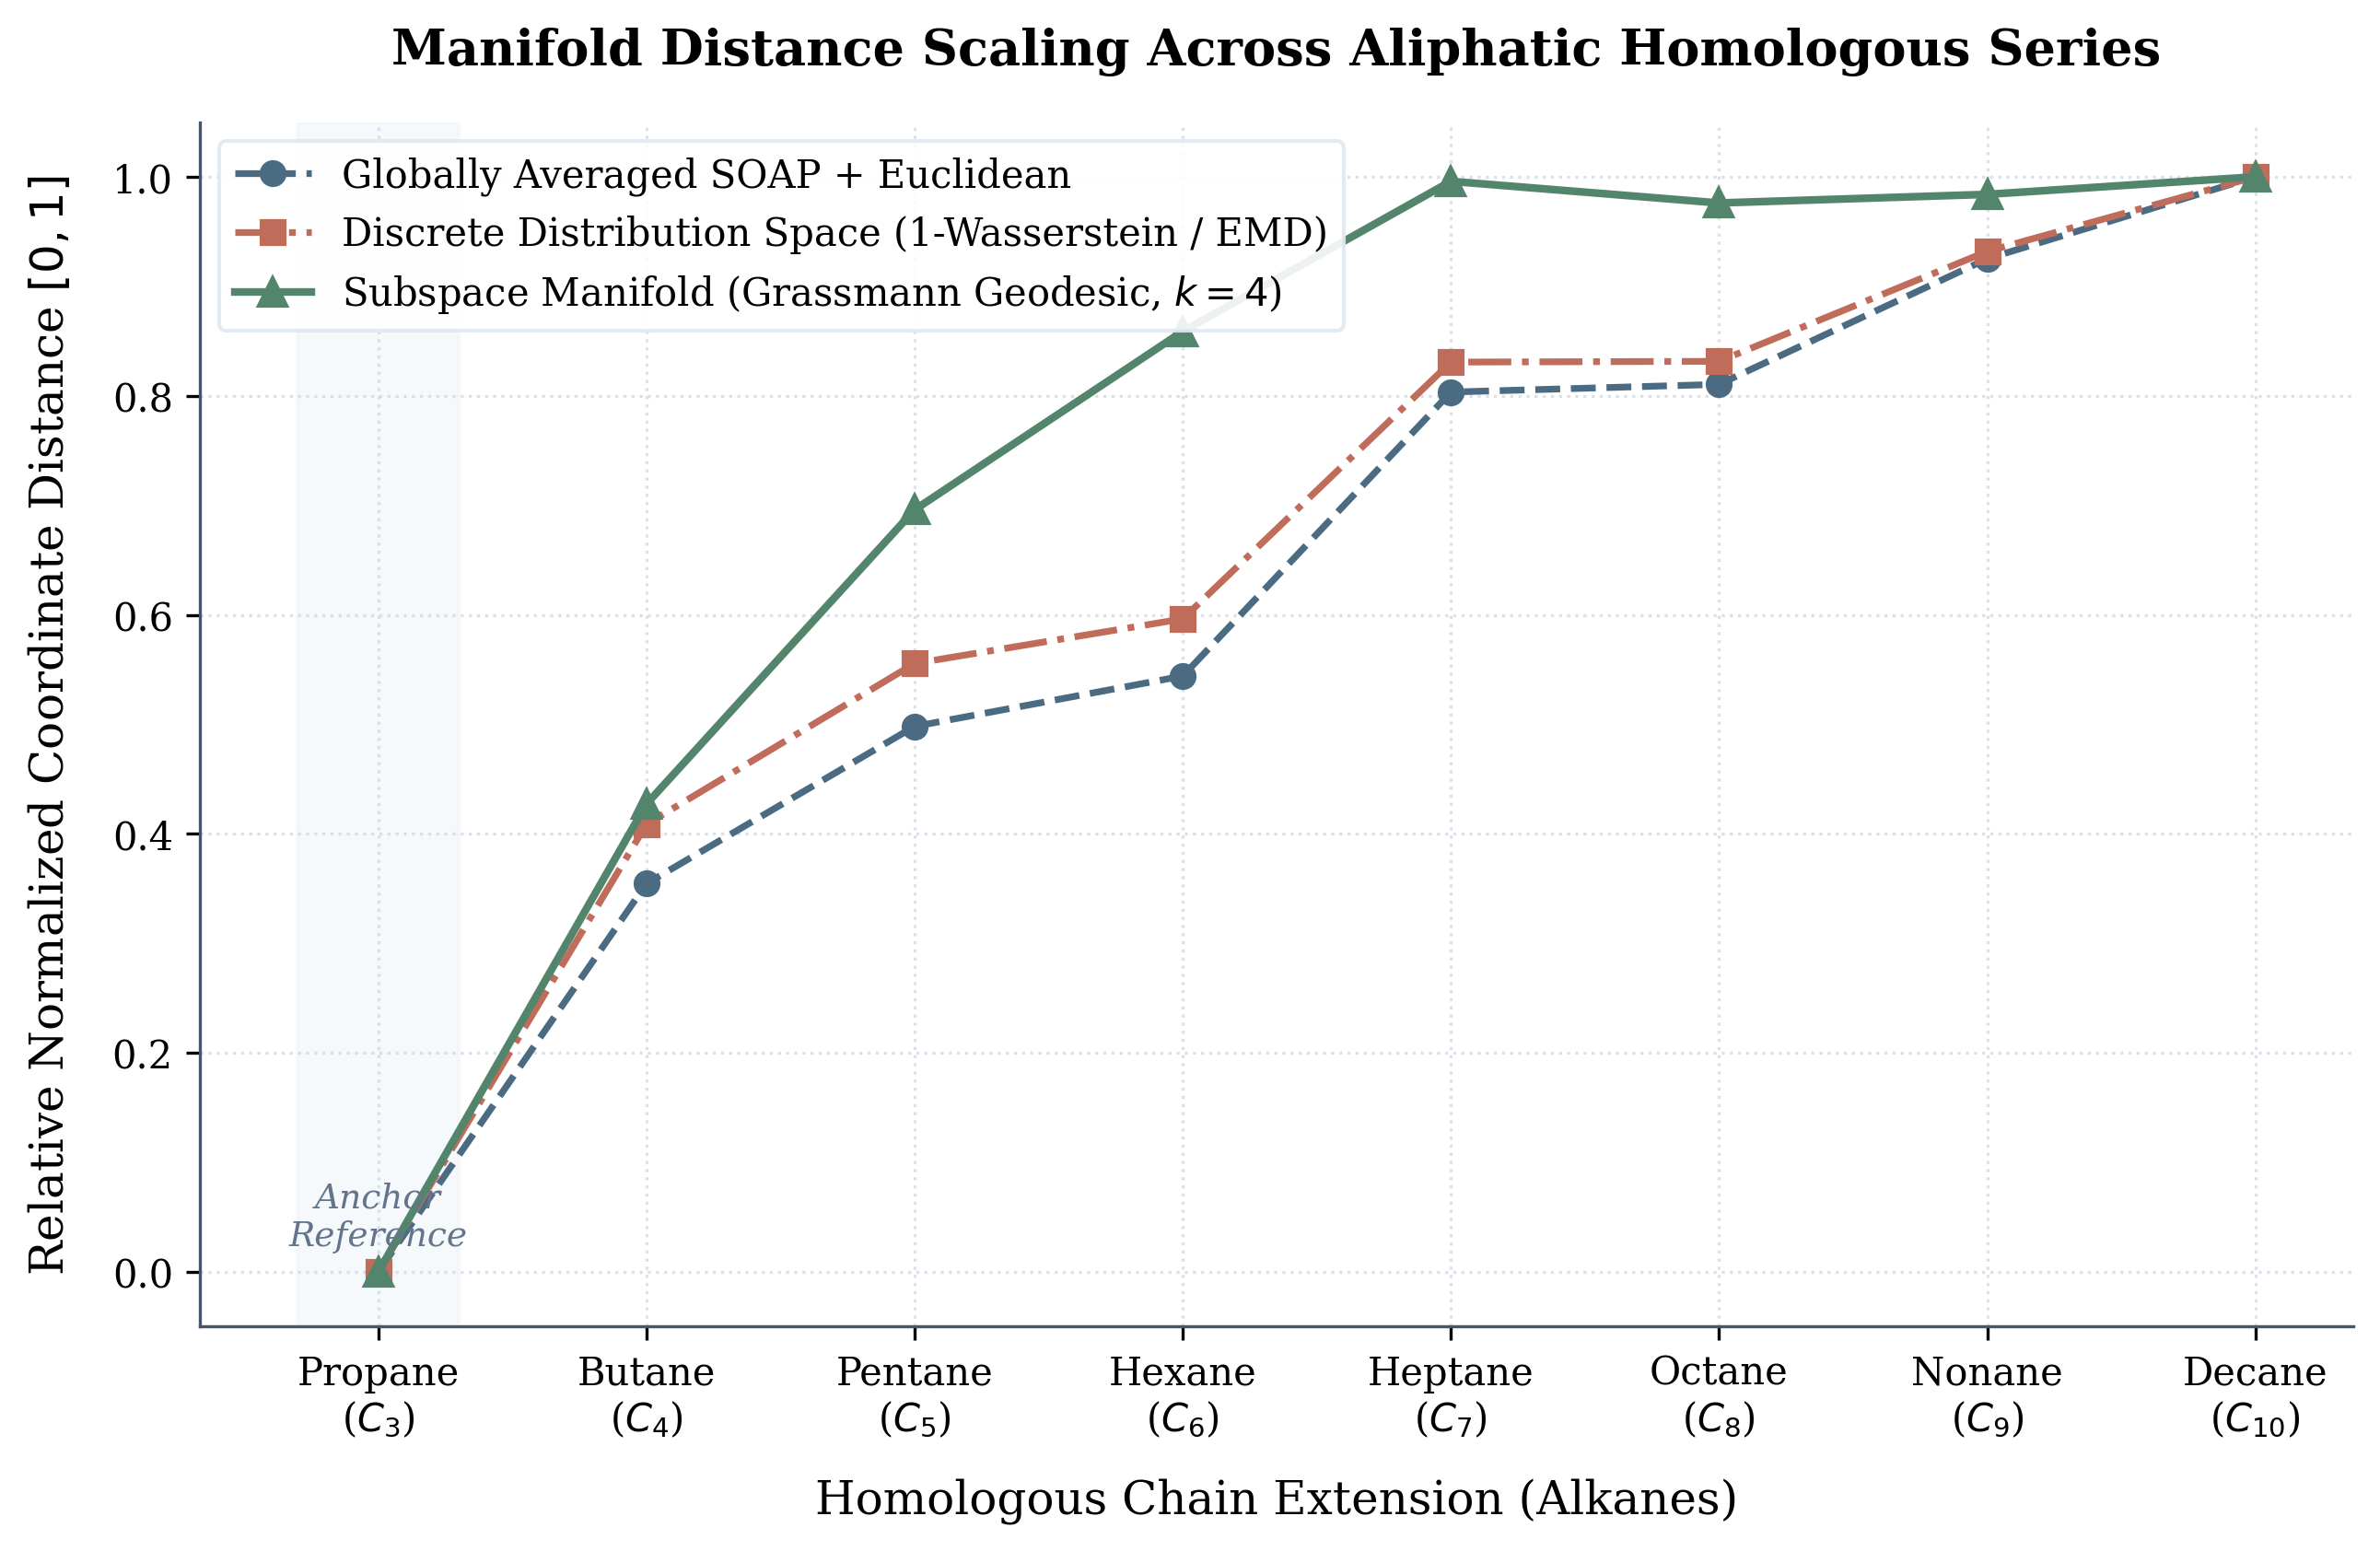

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
from ase import Atoms
import ot  # Python Optimal Transport library
from dscribe.descriptors import SOAP
from rdkit import Chem
from rdkit.Chem import AllChem

# =============================================================================
# 1. GENERATION OF HOMOLOGOUS SERIES
# =============================================================================
def generate_alkane_geometries():
    """Generates optimized 3D structures for alkanes from Propane (C3) to Decane (C10)."""
    smiles_dict = {
        "Propane\n($C_3$)": "CCC",
        "Butane\n($C_4$)": "CCCC",
        "Pentane\n($C_5$)": "CCCCC",
        "Hexane\n($C_6$)": "CCCCCC",
        "Heptane\n($C_7$)": "CCCCCCC",
        "Octane\n($C_8$)": "CCCCCCCC",
        "Nonane\n($C_9$)": "CCCCCCCCC",
        "Decane\n($C_{10}$)": "CCCCCCCCCC"
    }
    
    geometries = {}
    for name, smiles in smiles_dict.items():
        mol = Chem.MolFromSmiles(smiles)
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        AllChem.MMFFOptimizeMolecule(mol)
        
        conf = mol.GetConformer()
        positions = conf.GetPositions()
        atomic_numbers = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
        
        geometries[name] = Atoms(numbers=atomic_numbers, positions=positions)
    
    return geometries

# =============================================================================
# 2. METRIC ENGINES
# =============================================================================
def compute_euclidean_average(soap_A, soap_B):
    mean_A = np.mean(soap_A, axis=0)
    mean_B = np.mean(soap_B, axis=0)
    return np.linalg.norm(mean_A - mean_B)

def compute_exact_wasserstein(soap_A, soap_B):
    n_A = soap_A.shape[0]
    n_B = soap_B.shape[0]
    w_A = np.ones(n_A) / n_A
    w_B = np.ones(n_B) / n_B
    cost_matrix = ot.dist(soap_A, soap_B, metric='euclidean')
    return float(ot.emd2(w_A, w_B, cost_matrix))

def compute_grassmann_geodesic(soap_A, soap_B, k=4):
    _, _, Vh_A = np.linalg.svd(soap_A, full_matrices=False)
    _, _, Vh_B = np.linalg.svd(soap_B, full_matrices=False)
    
    Y_A = Vh_A[:k, :].T  
    Y_B = Vh_B[:k, :].T  
    
    inner_product = np.dot(Y_A.T, Y_B)
    sigma = np.clip(np.linalg.svd(inner_product, compute_uv=False), -1.0, 1.0)
    principal_angles = np.arccos(sigma)
    return np.sqrt(np.sum(principal_angles**2))

# =============================================================================
# 3. EXECUTION PIPELINE & GRAPH GENERATION
# =============================================================================
if __name__ == "__main__":
    alkanes = generate_alkane_geometries()
    names = list(alkanes.keys())
    num_molecules = len(names)
    
    soap_config = SOAP(
        species=["H", "C"],
        periodic=False,
        r_cut=5.0,
        n_max=6,
        l_max=4,
        sigma=0.5
    )
    
    soap_matrices = {name: soap_config.create(atoms) for name, atoms in alkanes.items()}
    
    dist_euclidean = np.zeros(num_molecules)
    dist_wasserstein = np.zeros(num_molecules)
    dist_grassmann = np.zeros(num_molecules)
    
    # Calculate structural trajectories relative to the first index (Propane)
    for j in range(num_molecules):
        dist_euclidean[j] = compute_euclidean_average(soap_matrices[names[0]], soap_matrices[names[j]])
        dist_wasserstein[j] = compute_exact_wasserstein(soap_matrices[names[0]], soap_matrices[names[j]])
        dist_grassmann[j] = compute_grassmann_geodesic(soap_matrices[names[0]], soap_matrices[names[j]], k=4)
            
    # Scale profiles uniformly to [0, 1] relative to maximum observed divergence bounds
    dist_euclidean /= np.max(dist_euclidean)
    dist_wasserstein /= np.max(dist_wasserstein)
    dist_grassmann /= np.max(dist_grassmann)
    
    # --- Establish Publication Theme Layout ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 14
    })
    
    fig, ax = plt.subplots(figsize=(8.5, 5.5), layout="constrained", dpi=300)
    
    # Editorial color scheme selection
    colors = ["#4A6B82", "#C06C5B", "#52856B"]
    
    # Plot curves with clean line styles and proportional sizing
    ax.plot(names, dist_euclidean, label="Globally Averaged SOAP + Euclidean", 
            color=colors[0], marker='o', markersize=6, linewidth=1.75, linestyle='--')
    ax.plot(names, dist_wasserstein, label="Discrete Distribution Space (1-Wasserstein / EMD)", 
            color=colors[1], marker='s', markersize=6, linewidth=1.75, linestyle='-.')
    ax.plot(names, dist_grassmann, label="Subspace Manifold (Grassmann Geodesic, $k=4$)", 
            color=colors[2], marker='^', markersize=7, linewidth=2.0, linestyle='-')
    
    # Titles and structural bounds labels
    ax.set_title("Manifold Distance Scaling Across Aliphatic Homologous Series", 
                 fontweight="bold", fontsize=13, pad=15)
    ax.set_xlabel("Homologous Chain Extension (Alkanes)", fontweight="medium", labelpad=10)
    ax.set_ylabel("Relative Normalized Coordinate Distance $[0,1]$", fontweight="medium", labelpad=10)
    
    # Clean up baseline boundaries and grid visibility
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=":", color="#cbd5e1", alpha=0.7, zorder=0)
    
    # Highlight the origin reference anchor (Propane)
    ax.axvspan(-0.3, 0.3, color="#f1f5f9", alpha=0.6, zorder=1)
    ax.text(0.0, 0.05, "Anchor\nReference", color="#64748b", fontsize=9, 
            fontstyle="italic", ha="center", va="center", weight="medium")

    # Clean border styling
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#475569")
    ax.spines["bottom"].set_color("#475569")
    
    # Place descriptive legend block
    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#e2e8f0", 
              framealpha=0.9, shadow=False, fontsize=10)
    
    # Export and show rendering
    #plt.savefig("thesis_homologous_scaling.png", bbox_inches="tight", dpi=300)
    plt.show()